# Training the first PyTorch Model: Card Classifier

This notebook is an independent walkthrough and implementation based on a tutorial by Rob Mulla. 

**Attributions:**
* **Learning Resource:** [Train Your first PyTorch Model [Card Classifier]](https://www.kaggle.com/code/robikscube/train-your-first-pytorch-model-card-classifier) by Rob Mulla.
* **Dataset:** [Cards Image Dataset-Classification](https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification) 

Project: to create an image classifier to detect playing cards

we will have three parts
1. Pytorch Dataset
2. Pytorch Model
3. Pytorch Training Loop

In [1]:
import torch # imports the main PyTorch library
import torch.nn as nn # imports the neural network module
import torch.optim as optim # optimization algorithms; updates the weight of our nn based on the loss calculated during training
from torch.utils.data import Dataset, DataLoader # classes for feeding data into the model
import torchvision # library for computer vision tasks, companion libray for PyTorch
import torchvision.transforms as transforms # this module contains functions for image manipulation and preprocessing
from torchvision.datasets import ImageFolder # automatically builds a Dataset for us without needing to write custom parsing code
import timm # 'PyTorch Image Models' - open source library that contains 100s of pre-trained state of the art computer vision models

import matplotlib.pyplot as plt
import pandas as pd # to deal with data frames
import numpy as np # fundamental package for scientific computing
import sys # provides access to system specific parameters and functions
from tqdm.notebook import tqdm # helps to create progress bars

print('System ver:', sys.version)
print('PyTorch ver:', torch.__version__)
print('Torchvision ver:', torchvision.__version__)
print('Numpy ver:', np.__version__)
print('Pandas ver:', pd.__version__)

System ver: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch ver: 2.9.0+cpu
Torchvision ver: 0.24.0+cpu
Numpy ver: 2.0.2
Pandas ver: 2.3.3


### Step 1: PyTorch Dataset and Dataloader

- datasets are an organized way to structure how the data and labels are loaded into the model.
- we can then wrap the dataset in a dataloader and pytorch will handle batching, shuffling of data, for us when training the model.

In [2]:
class PlayingCardDataset(Dataset):
    def __init__(self, data_dir, transform = None):
        self.data = ImageFolder(data_dir, transform = transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


    #property
    def classes(self):
        return self.data.classes



In [3]:
dataset = PlayingCardDataset(
    data_dir = '/kaggle/input/datasets/gpiosenka/cards-image-datasetclassification/train'
)

In [4]:
len(dataset)

7624

In [5]:
dataset[5]

(<PIL.Image.Image image mode=RGB size=224x224>, 0)

37


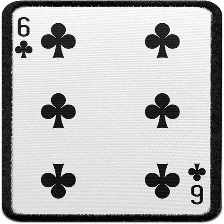

In [6]:
image, label = dataset[5400]
print(label)
image

In [7]:
# Get a dicitionary associating target values with folder names
data_dir = '/kaggle/input/datasets/gpiosenka/cards-image-datasetclassification/train'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'ace of clubs', 1: 'ace of diamonds', 2: 'ace of hearts', 3: 'ace of spades', 4: 'eight of clubs', 5: 'eight of diamonds', 6: 'eight of hearts', 7: 'eight of spades', 8: 'five of clubs', 9: 'five of diamonds', 10: 'five of hearts', 11: 'five of spades', 12: 'four of clubs', 13: 'four of diamonds', 14: 'four of hearts', 15: 'four of spades', 16: 'jack of clubs', 17: 'jack of diamonds', 18: 'jack of hearts', 19: 'jack of spades', 20: 'joker', 21: 'king of clubs', 22: 'king of diamonds', 23: 'king of hearts', 24: 'king of spades', 25: 'nine of clubs', 26: 'nine of diamonds', 27: 'nine of hearts', 28: 'nine of spades', 29: 'queen of clubs', 30: 'queen of diamonds', 31: 'queen of hearts', 32: 'queen of spades', 33: 'seven of clubs', 34: 'seven of diamonds', 35: 'seven of hearts', 36: 'seven of spades', 37: 'six of clubs', 38: 'six of diamonds', 39: 'six of hearts', 40: 'six of spades', 41: 'ten of clubs', 42: 'ten of diamonds', 43: 'ten of hearts', 44: 'ten of spades', 45: 'three of clu

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)), # this line ensures that every single image is forcefully resized to a size of 128px by 128px
    transforms.ToTensor(), # neural networks cannot read JPEGs or PNGs directly, they only understand matrices of numbers (tensors). This function helps with 'format conversion' to (Channels x Height x Width) and pixel scaling to between 0.0 amd 1.0
])

data_dir = '/kaggle/input/datasets/gpiosenka/cards-image-datasetclassification/train'
dataset = PlayingCardDataset(data_dir, transform)

In [9]:
image, label = dataset[500]
image.shape

torch.Size([3, 128, 128])

In [10]:
# iterating over the dataset - its iterable - we will break out here - leaving it here just to demonstrate
for image, label in dataset:
    break

In [11]:
image

tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [0.0784, 0.0824, 0.0745,  ..., 1.0000, 1.0000, 1.0000],
         [0.7490, 0.7451, 0.7412,  ..., 1.0000, 1.0000, 1.0000],
         [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [0.0745, 0.0784, 0.0706,  ..., 1.0000, 1.0000, 1.0000],
         [0.7451, 0.7451, 0.7373,  ..., 1.0000, 1.0000, 1.0000],
         [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.

In [12]:
label

0